In [8]:
#Project Name : Global Economic Growth Prediction and Financial Risk Analysis Using World Bank Data
#Objective : To predict GDP Growth (annual %) using World Bank economic indicators and analyze the financial risk of different countries.

#Required Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import warnings
warnings.filterwarnings("ignore")

In [9]:
# Load the Dataset
df = pd.read_csv("World_Bank_Data.csv")
df.head()
df.shape

(1305, 20)

In [10]:
# Data Cleaning

df.replace("..", np.nan, inplace=True)
df.drop_duplicates(inplace=True)

# Convert year columns:
year_columns = df.columns[4:]

df[year_columns] = df[year_columns].apply(
    pd.to_numeric,
    errors="coerce"
)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1303 entries, 0 to 1304
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Country Name   1302 non-null   object 
 1   Country Code   1300 non-null   object 
 2   Series Name    1300 non-null   object 
 3   Series Code    1300 non-null   object 
 4   2010 [YR2010]  1113 non-null   float64
 5   2011 [YR2011]  1111 non-null   float64
 6   2012 [YR2012]  1120 non-null   float64
 7   2013 [YR2013]  1143 non-null   float64
 8   2014 [YR2014]  1142 non-null   float64
 9   2015 [YR2015]  1146 non-null   float64
 10  2016 [YR2016]  1155 non-null   float64
 11  2017 [YR2017]  1152 non-null   float64
 12  2018 [YR2018]  1156 non-null   float64
 13  2019 [YR2019]  1150 non-null   float64
 14  2020 [YR2020]  1145 non-null   float64
 15  2021 [YR2021]  1116 non-null   float64
 16  2022 [YR2022]  1097 non-null   float64
 17  2023 [YR2023]  1051 non-null   float64
 18  2024 [YR2024]

In [11]:
df_long = df.melt(
    id_vars=[
        "Country Name",
        "Country Code",
        "Series Name",
        "Series Code"
    ],
    var_name="Year",
    value_name="Value"
)
# Extract the 4-digit year from values like "2010 [YR2010]"
df_long["Year"] = df_long["Year"].str.extract(r'(\d{4})')

# Convert to integer
df_long["Year"] = pd.to_numeric(df_long["Year"])

# Remove rows where Year couldn't be extracted
df_long.dropna(subset=["Year"], inplace=True)

df_long["Year"] = df_long["Year"].astype(int)

df_long.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20848 entries, 0 to 20847
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Name  20832 non-null  object 
 1   Country Code  20800 non-null  object 
 2   Series Name   20800 non-null  object 
 3   Series Code   20800 non-null  object 
 4   Year          20848 non-null  int64  
 5   Value         17333 non-null  float64
dtypes: float64(1), int64(1), object(4)
memory usage: 977.4+ KB


In [12]:
df_long.dropna(subset=["Value"], inplace=True)
df_long["Value"] = pd.to_numeric(df_long["Value"], errors="coerce")

In [13]:
df_ml = df_long.pivot_table(
    index=[
        "Country Name",
        "Country Code",
        "Year"
    ],
    columns="Series Name",
    values="Value"
).reset_index()

In [14]:
numeric_cols = df_ml.select_dtypes(include=np.number).columns

df_ml[numeric_cols] = df_ml[numeric_cols].fillna(
    df_ml[numeric_cols].median()
)

In [15]:
df_ml.shape

(320, 68)

In [16]:
df_ml.head()

Series Name,Country Name,Country Code,Year,"Adolescent fertility rate (births per 1,000 women ages 15-19)","Agriculture, forestry, and fishing, value added (% of GDP)","Agriculture, forestry, and fishing, value added (annual % growth)","Annual freshwater withdrawals, total (% of internal resources)",Births attended by skilled health staff (% of total),"Central government debt, total (% of GDP)","Contraceptive prevalence, any method (% of married women ages 15-49)",...,"School enrollment, secondary (% gross)","Services, value added (% of GDP)","Services, value added (annual % growth)",Surface area (sq. km),Tax revenue (% of GDP),Terrestrial and marine protected areas (% of total territorial area),"Total debt service (% of exports of goods, services and primary income)","Unemployment, total (% of total labor force) (modeled ILO estimate)","Unemployment, total (% of total labor force) (national estimate)",Urban population growth (annual %)
0,Argentina,ARG,2010,65.927,7.132167,39.523978,12.679008,95.0,49.93106,66.93000,...,99.070999,51.495180,7.089824,2780400.0,12.853043,14.7,18.642455,7.714,7.714,1.245680
1,Argentina,ARG,2011,66.764,6.998734,-2.428483,12.907534,97.1,49.93106,66.93000,...,100.884560,51.811901,6.444827,2780400.0,12.663628,14.7,15.654928,7.180,7.180,1.190193
2,Argentina,ARG,2012,64.852,5.781744,-12.875153,12.907534,98.2,49.93106,66.93000,...,102.709991,53.658118,0.668753,2780400.0,12.952842,14.7,14.066678,7.217,7.217,1.133954
3,Argentina,ARG,2013,66.104,6.052918,11.476620,12.907534,97.0,49.93106,72.37021,...,104.540863,53.919094,1.909762,2780400.0,12.452903,5.0,17.137319,7.100,7.100,1.099618
4,Argentina,ARG,2014,66.613,6.712704,3.104253,12.907534,99.6,49.93106,66.93000,...,106.038902,52.940543,-1.644378,2780400.0,12.610967,7.3,20.169582,7.268,7.268,1.136926


In [17]:
selected_columns = [
    "Country Name",
    "Country Code",
    "Year",
    "GDP growth (annual %)",
    "GDP (current US$)",
    "Gross capital formation (% of GDP)",
    "Gross savings (% of GDP)",
    "Inflation, consumer prices (annual %)",
    "Exports of goods and services (% of GDP)",
    "Imports of goods and services (% of GDP)",
    "Foreign direct investment, net inflows (% of GDP)",
    "Current account balance (% of GDP)",
    "Real interest rate (%)",
    "Domestic credit to private sector (% of GDP)",
    "Central government debt, total (% of GDP)",
    "Population growth (annual %)",
    "Population, total",
    "Unemployment, total (% of total labor force) (modeled ILO estimate)"
]

df_project = df_ml[selected_columns].copy()

In [18]:
df_project.isnull().sum()

Series Name
Country Name                                                           0
Country Code                                                           0
Year                                                                   0
GDP growth (annual %)                                                  0
GDP (current US$)                                                      0
Gross capital formation (% of GDP)                                     0
Gross savings (% of GDP)                                               0
Inflation, consumer prices (annual %)                                  0
Exports of goods and services (% of GDP)                               0
Imports of goods and services (% of GDP)                               0
Foreign direct investment, net inflows (% of GDP)                      0
Current account balance (% of GDP)                                     0
Real interest rate (%)                                                 0
Domestic credit to private sector (% of

In [19]:
numeric_cols = df_project.select_dtypes(include='number').columns

df_project[numeric_cols] = df_project[numeric_cols].fillna(
    df_project[numeric_cols].median()
)

(320, 14)
(320,)


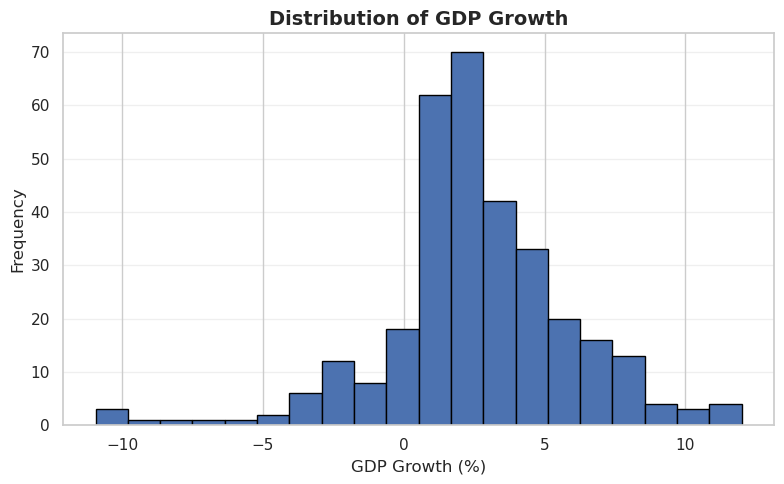

In [20]:
#GDP Growth Distribution
import matplotlib.pyplot as plt
plt.style.use('default')
sns.set_theme(style='whitegrid', context='notebook')
FIG_DPI = 300
FIG_SIZE = (10, 6)
X = df_project.drop(columns=[
    "Country Name",
    "Country Code",
    "Year",
    "GDP growth (annual %)"
])

y = df_project["GDP growth (annual %)"]
print(X.shape)
print(y.shape)

#----------
plt.figure(figsize=(8,5))

plt.hist(
    df_project['GDP growth (annual %)'],
    bins=20,
    edgecolor='black'
)

plt.title('Distribution of GDP Growth', fontsize=14, weight='bold')
plt.xlabel('GDP Growth (%)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('gdp_distribution.png', dpi=FIG_DPI, bbox_inches='tight')
plt.show()

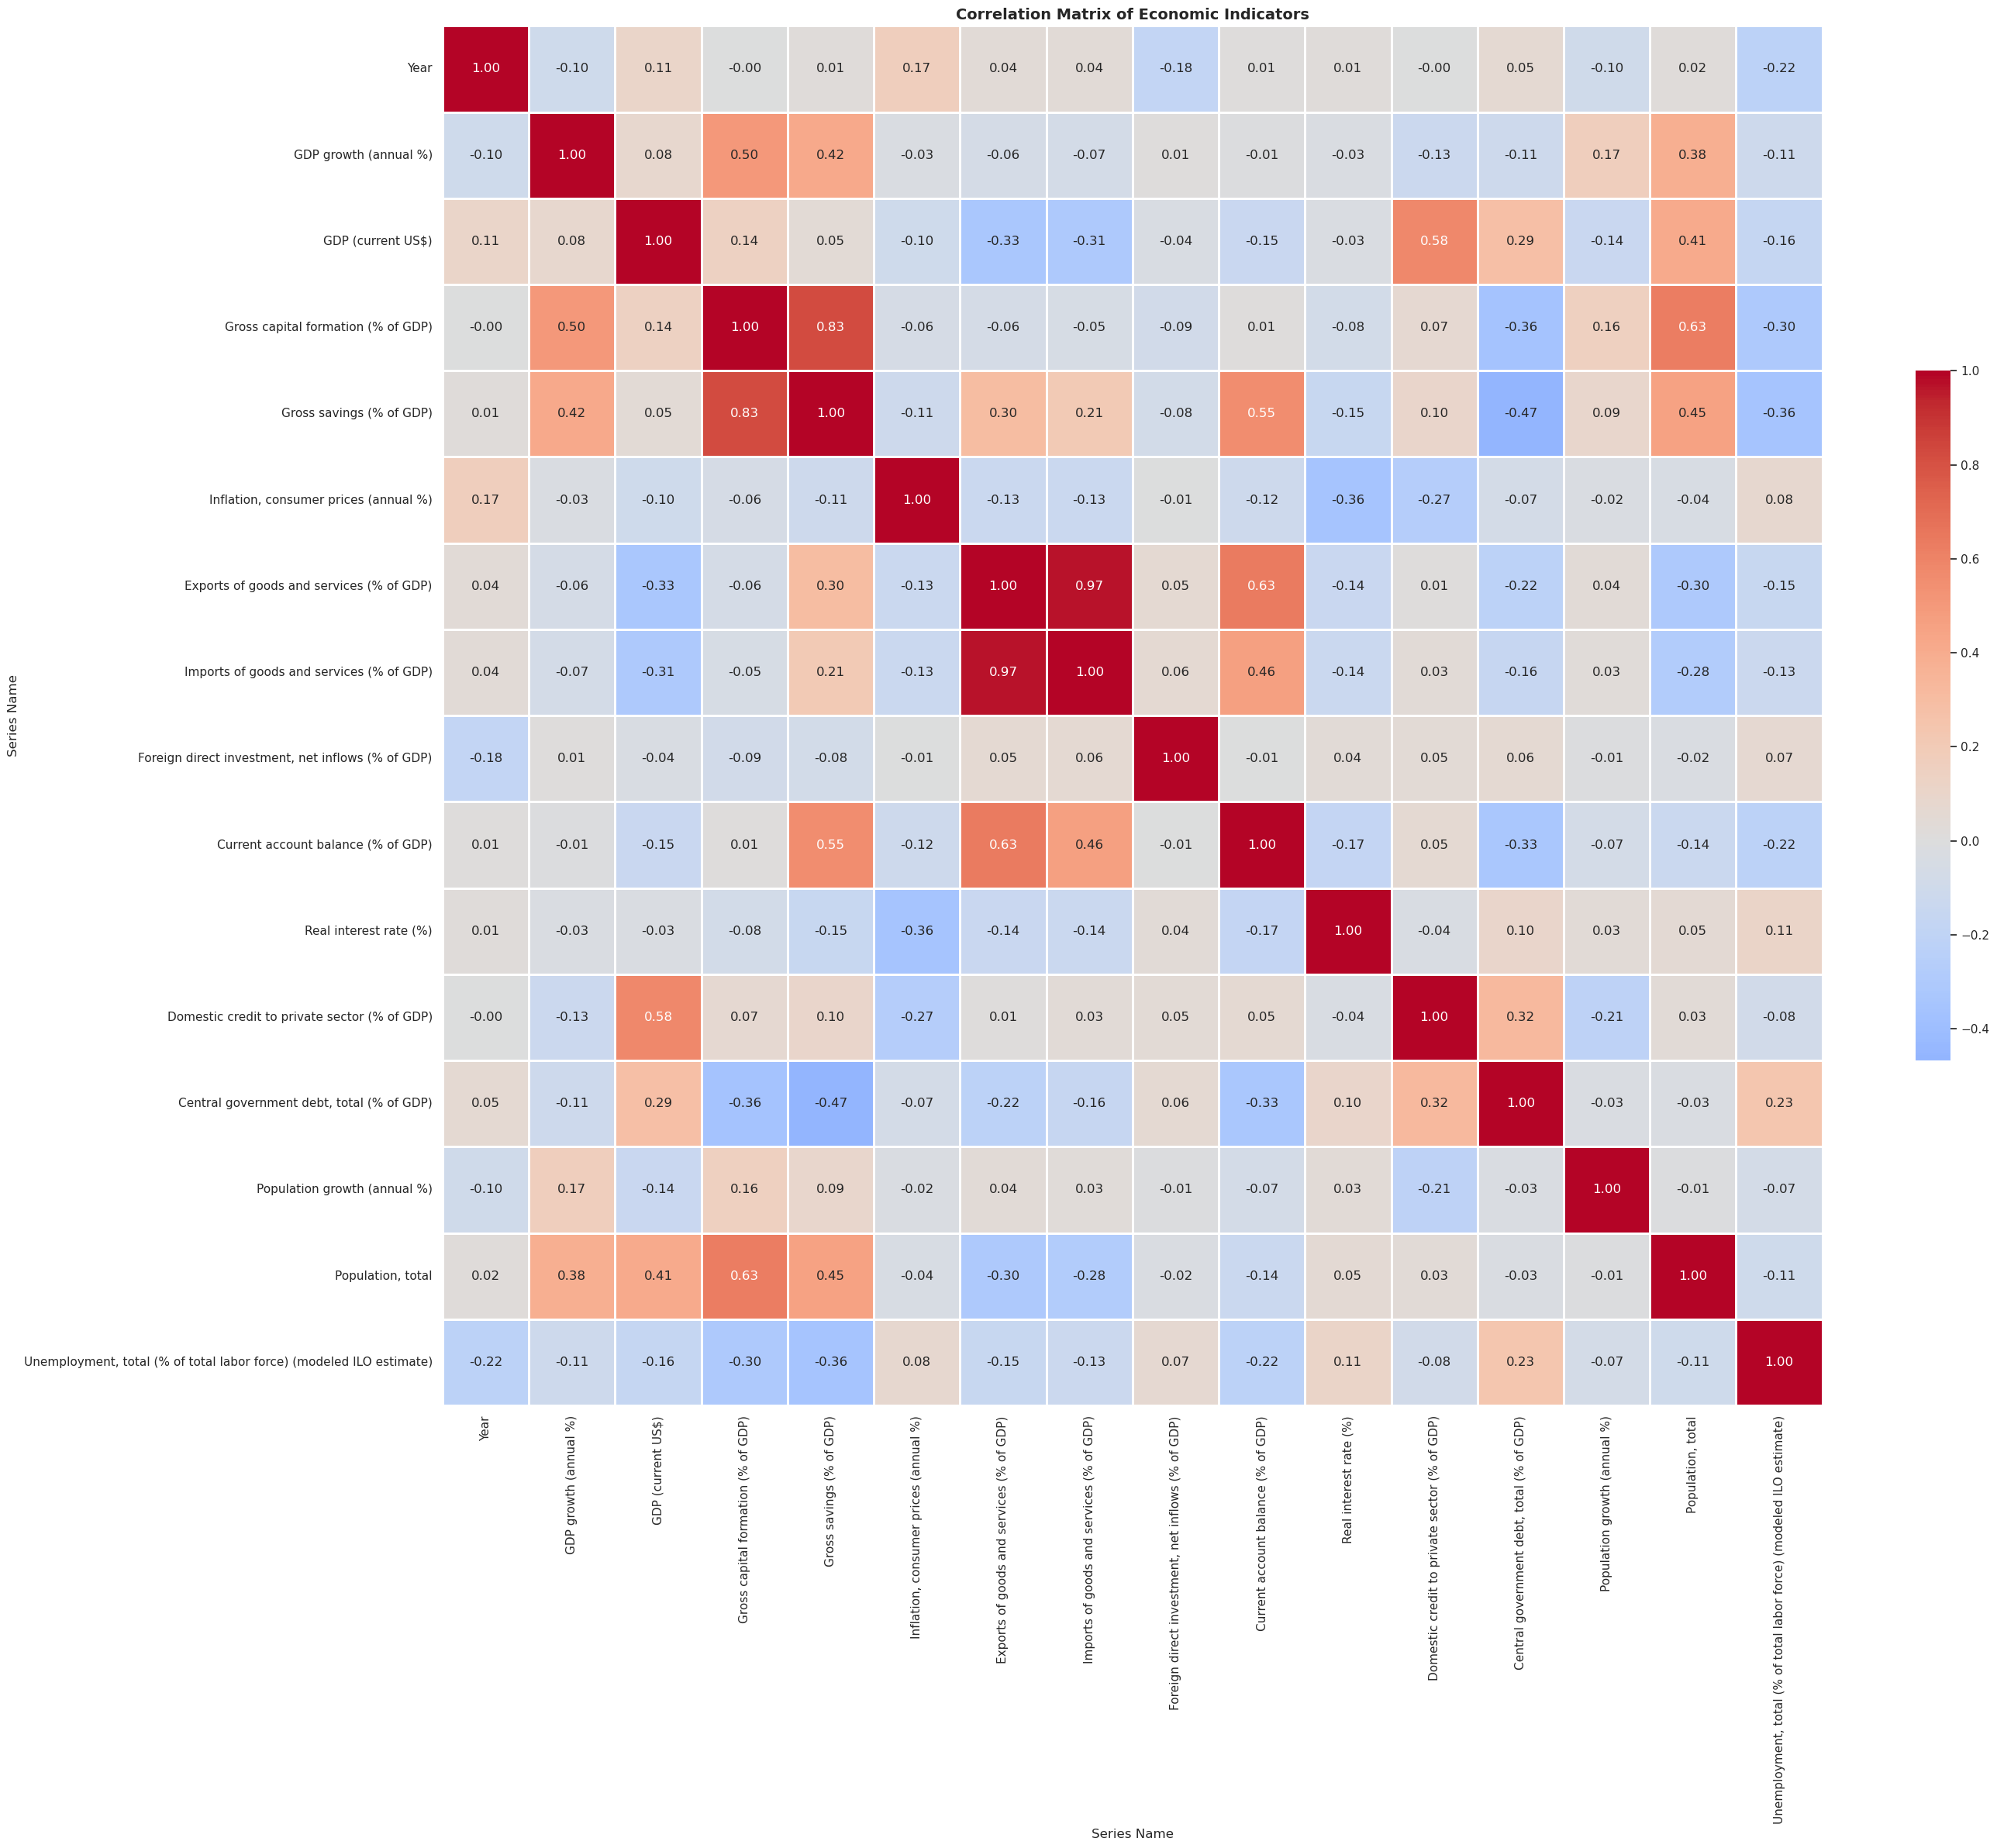

In [21]:
# Correlation Heatmap - Identifies relationships among the selected economic indicators.
numeric_df = df_project.select_dtypes(include='number')
corr = numeric_df.corr()

plt.figure(figsize=(30,24))

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0,
    annot=True,
    fmt='.2f',
    square=True,
    linewidths=2,
    cbar_kws={'shrink': 0.5}
)

plt.title('Correlation Matrix of Economic Indicators', fontsize=14, weight='bold')

plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=FIG_DPI, bbox_inches='tight')
plt.show()

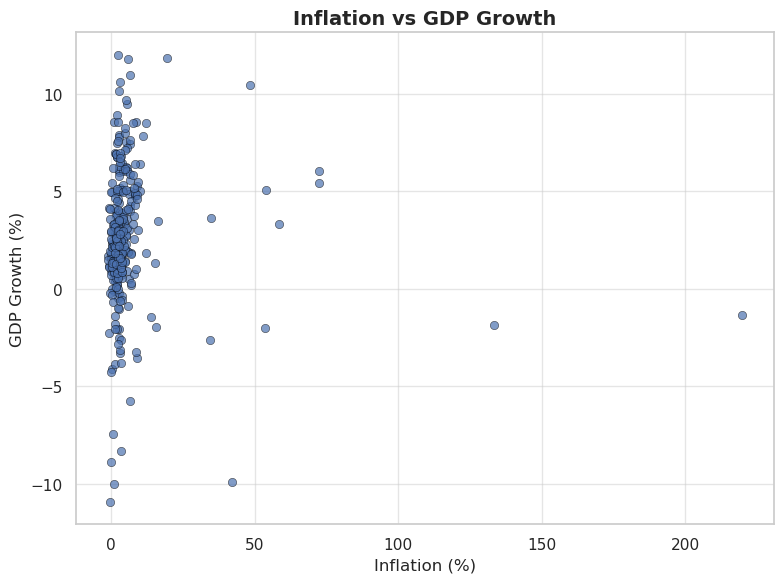

In [22]:

#Inflation vs GDP Growth (Scatter Plot)
plt.figure(figsize=(8,6))

plt.scatter(
    df_project['Inflation, consumer prices (annual %)'],
    df_project['GDP growth (annual %)'],
    alpha=0.7,
    edgecolors='black',
    linewidths=0.4
)

plt.title('Inflation vs GDP Growth', fontsize=14, weight='bold')
plt.xlabel('Inflation (%)')
plt.ylabel('GDP Growth (%)')
plt.grid(alpha=0.5)

plt.tight_layout()
plt.savefig('inflation_vs_gdp.png', dpi=FIG_DPI, bbox_inches='tight')
plt.show()

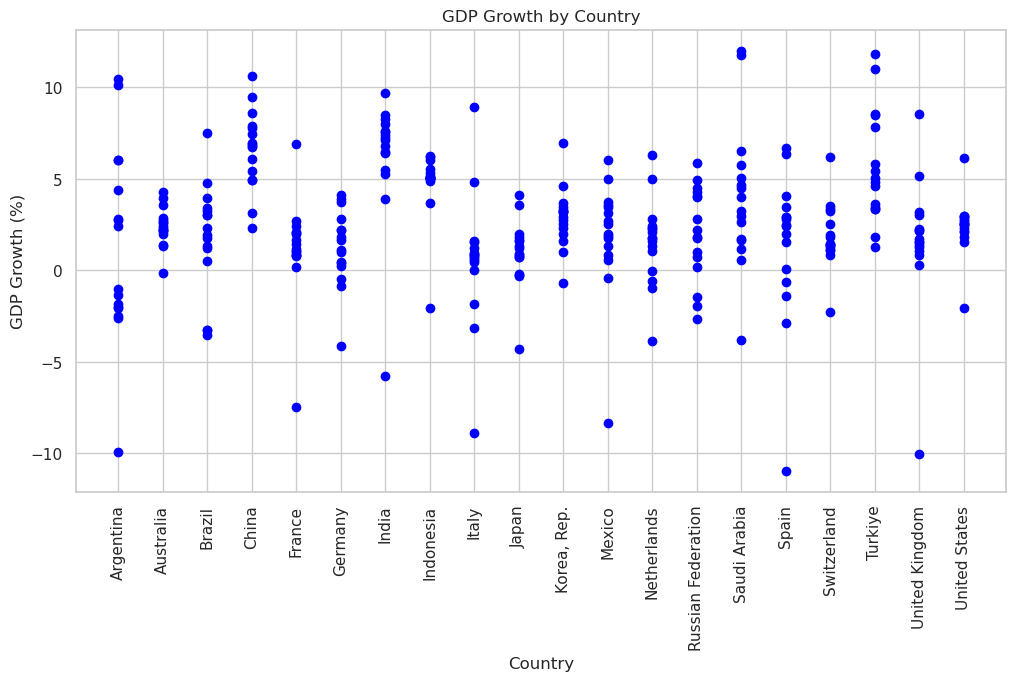

In [23]:
plt.figure(figsize=(12,6))

plt.scatter(
    df_project["Country Name"],
    df_project["GDP growth (annual %)"],
    color="blue"
)

plt.xticks(rotation=90)

plt.xlabel("Country")
plt.ylabel("GDP Growth (%)")
plt.title("GDP Growth by Country")

plt.show()

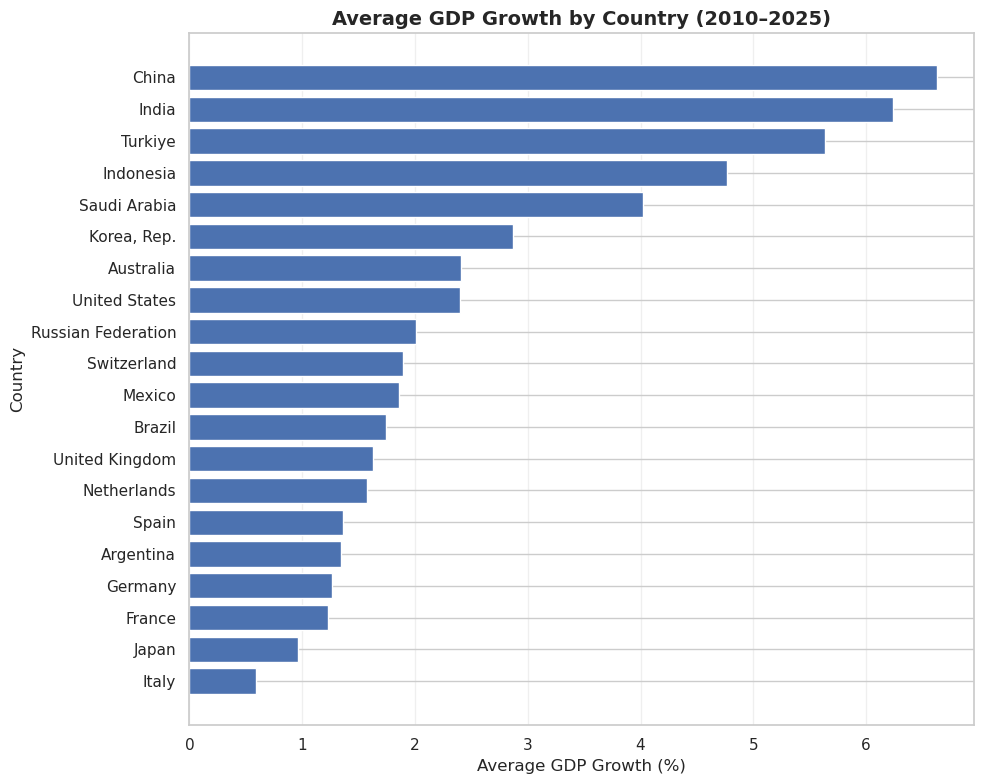

In [24]:
#Average GDP Growth by Country (Horizontal Bar Chart)
#Compares countries by their average GDP growth over 2010–2025.

country_gdp = (
    df_project
    .groupby('Country Name')['GDP growth (annual %)']
    .mean()
    .sort_values()
)

plt.figure(figsize=(10,8))

plt.barh(country_gdp.index, country_gdp.values)

plt.title('Average GDP Growth by Country (2010–2025)', fontsize=14, weight='bold')
plt.xlabel('Average GDP Growth (%)')
plt.ylabel('Country')
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('avg_gdp_growth_country.png', dpi=FIG_DPI, bbox_inches='tight')
plt.show()

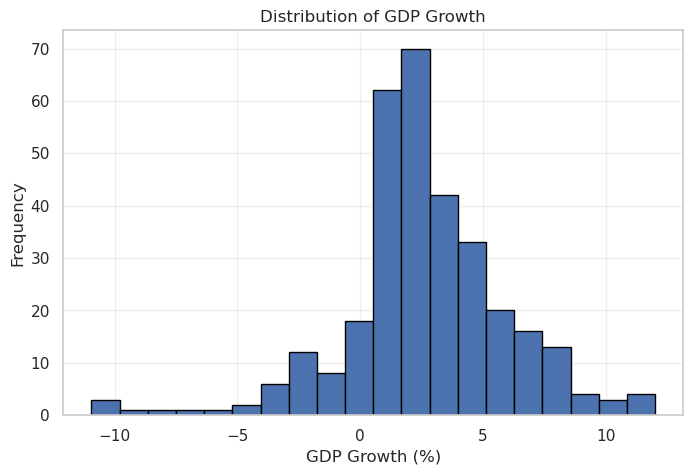

In [25]:
plt.figure(figsize=(8,5))

plt.hist(df_project["GDP growth (annual %)"],
         bins=20,
         edgecolor="black")

plt.title("Distribution of GDP Growth")
plt.xlabel("GDP Growth (%)")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()

In [26]:
df_project["Risk Score"] = (
    0.4 * df_project["Inflation, consumer prices (annual %)"] +
    0.3 * df_project["Central government debt, total (% of GDP)"] -
    0.3 * df_project["GDP growth (annual %)"]
)
country_risk = (
    df_project
    .groupby("Country Name")["Risk Score"]
    .mean()
    .sort_values(ascending=False)
)

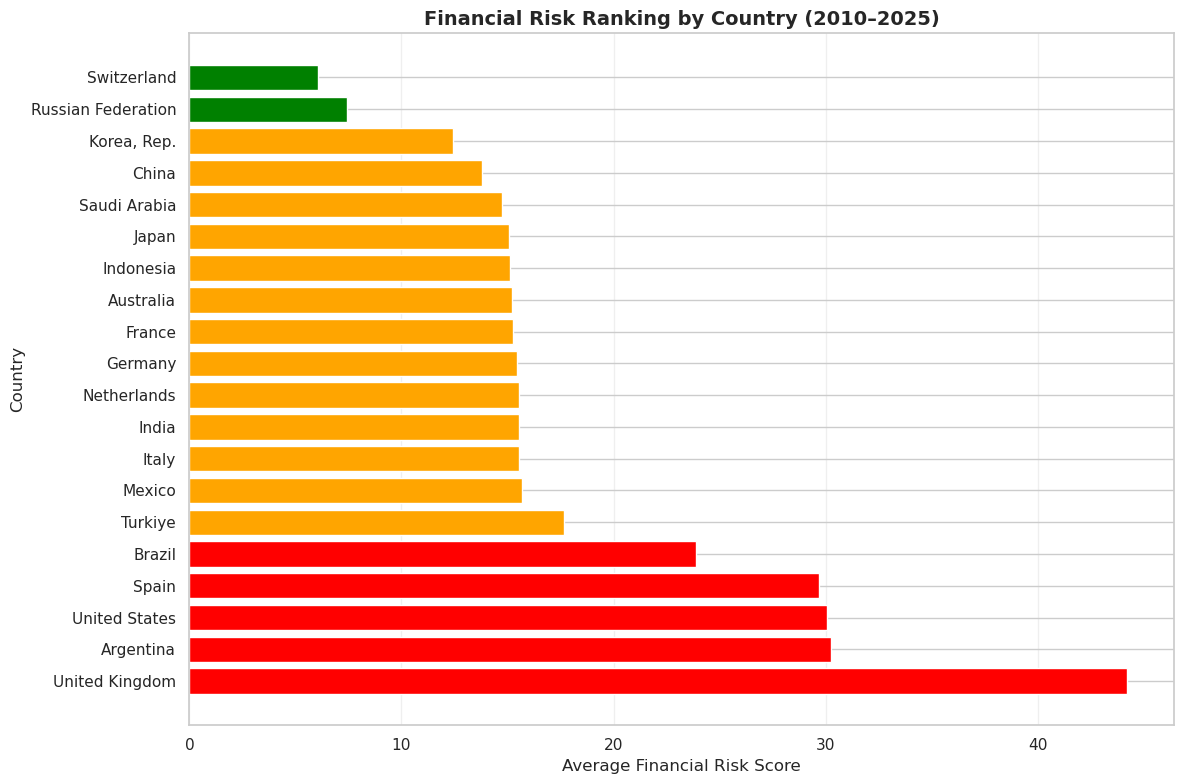

In [27]:
#Financial Risk Ranking by Country (Horizontal Bar Chart)
#Ranks countries by their average financial risk score
country_risk = (
    df_project
    .groupby('Country Name')['Risk Score']
    .mean()
    .sort_values(ascending=False)
)

colors = [
    'red' if score > 20
    else 'orange' if score > 10
    else 'green'
    for score in country_risk.values
]

plt.figure(figsize=(12,8))

plt.barh(
    country_risk.index,
    country_risk.values,
    color=colors
)

plt.title('Financial Risk Ranking by Country (2010–2025)', fontsize=14, weight='bold')
plt.xlabel('Average Financial Risk Score')
plt.ylabel('Country')
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('financial_risk_ranking.png', dpi=FIG_DPI, bbox_inches='tight')
plt.show()

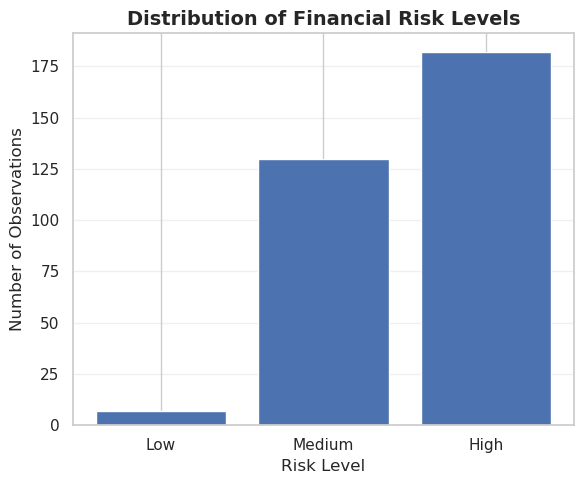

In [28]:
#Financial Risk Level Distribution (Count Plot)
#Shows how many observations fall into Low, Medium, and High risk categories.
df_project["Risk Level"] = pd.cut(
    df_project["Risk Score"],
    bins=[-100, 5, 15, 100],
    labels=["Low", "Medium", "High"]
)
risk_counts = df_project['Risk Level'].value_counts().reindex(['Low','Medium','High'])

plt.figure(figsize=(6,5))

plt.bar(risk_counts.index, risk_counts.values)

plt.title('Distribution of Financial Risk Levels', fontsize=14, weight='bold')
plt.xlabel('Risk Level')
plt.ylabel('Number of Observations')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('risk_level_distribution.png', dpi=FIG_DPI, bbox_inches='tight')
plt.show()

In [29]:
# Report : The graph ranks countries based on their average financial risk score calculated using inflation, government debt, and GDP growth. Countries with higher scores indicate greater macroeconomic financial risk, while countries with lower scores demonstrate relatively stronger economic stability during the study period.

In [41]:
#Phase 3 – Feature Selection
#GDP Growth
y = df_project["GDP growth (annual %)"]
X = df_project.drop(columns=[
        "Country Name",
        "Country Code",
        "GDP growth (annual %)",
        "Risk Level"
])


In [42]:
#Phase 4 : Model Building
#A model should not be tested using the same data it learned from.

#80% Training

#20% Testing

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

#Feature Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = df_project.drop(columns=["Risk Level"])

y = df_project["Risk Level"]

X_train = scaler.fit_transform(X_train)


X_test = scaler.transform(X_test)

In [43]:
#First Model is Linear Regression
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [44]:
#prediction 
pred_lr = lr.predict(X_test)
#Evaluation
print("MAE : ",mean_absolute_error(y_test,pred_lr))
print("RMSE : ",np.sqrt(mean_squared_error(y_test,pred_lr)))
print("R2 : ",r2_score(y_test,pred_lr))

MAE :  1.6740948904914177e-14
RMSE :  2.1207942291488005e-14
R2 :  1.0


In [45]:
#Random Forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train,y_train)
pred_rf = rf.predict(X_test)

In [46]:
print("MAE : ",mean_absolute_error(y_test,pred_rf))
print("RMSE : ",np.sqrt(mean_squared_error(y_test,pred_rf)))
print("R2 : ",r2_score(y_test,pred_rf))

MAE :  1.6101009262959176
RMSE :  2.3299132050673586
R2 :  0.3893437953553175


In [48]:

#Comparison
results = pd.DataFrame({
    "Model":["Linear Regression","Random Forest"],
    "MAE":[
        mean_absolute_error(y_test,pred_lr),
        mean_absolute_error(y_test,pred_rf)
    ],
    "RMSE":[
        np.sqrt(mean_squared_error(y_test,pred_lr)),
        np.sqrt(mean_squared_error(y_test,pred_rf))
    ],
    "R2":[
        r2_score(y_test,pred_lr),
        r2_score(y_test,pred_rf)
    ]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,1.674095e-14,2.120794e-14,1.000000
1,Random Forest,1.610101e+00,2.329913e+00,0.389344


In [53]:
X = df_project.drop(columns=[
    "Country Name",
    "Country Code",
    "GDP growth (annual %)",
    "Risk Level"
])

y = df_project["GDP growth (annual %)"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

feature_names = X.columns

importance = pd.Series(
    rf.feature_importances_,
    index=feature_names
).sort_values()

16
(320, 16)
Index(['Year', 'GDP (current US$)', 'Gross capital formation (% of GDP)',
       'Gross savings (% of GDP)', 'Inflation, consumer prices (annual %)',
       'Exports of goods and services (% of GDP)',
       'Imports of goods and services (% of GDP)',
       'Foreign direct investment, net inflows (% of GDP)',
       'Current account balance (% of GDP)', 'Real interest rate (%)',
       'Domestic credit to private sector (% of GDP)',
       'Central government debt, total (% of GDP)',
       'Population growth (annual %)', 'Population, total',
       'Unemployment, total (% of total labor force) (modeled ILO estimate)',
       'Risk Score'],
      dtype='object', name='Series Name')
['Year', 'GDP (current US$)', 'Gross capital formation (% of GDP)', 'Gross savings (% of GDP)', 'Inflation, consumer prices (annual %)', 'Exports of goods and services (% of GDP)', 'Imports of goods and services (% of GDP)', 'Foreign direct investment, net inflows (% of GDP)', 'Current account 

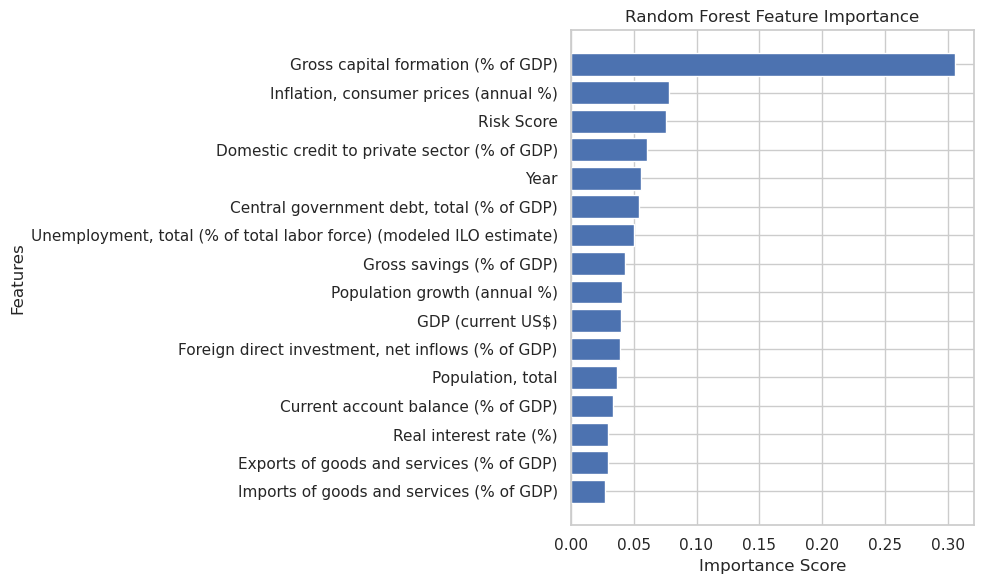

In [57]:
#Feature Importance (Random Forest)
print(len(rf.feature_importances_))
print(X.shape)
print(X.columns)
print(X.columns.tolist())

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values()

plt.figure(figsize=(10,6))
plt.barh(importance.index, importance.values)
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Random Forest Feature Importance")
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [58]:
print(X.columns.tolist())
print(len(rf.feature_importances_))
print(len(rf.feature_importances_))

['Year', 'GDP (current US$)', 'Gross capital formation (% of GDP)', 'Gross savings (% of GDP)', 'Inflation, consumer prices (annual %)', 'Exports of goods and services (% of GDP)', 'Imports of goods and services (% of GDP)', 'Foreign direct investment, net inflows (% of GDP)', 'Current account balance (% of GDP)', 'Real interest rate (%)', 'Domestic credit to private sector (% of GDP)', 'Central government debt, total (% of GDP)', 'Population growth (annual %)', 'Population, total', 'Unemployment, total (% of total labor force) (modeled ILO estimate)', 'Risk Score']
16
16


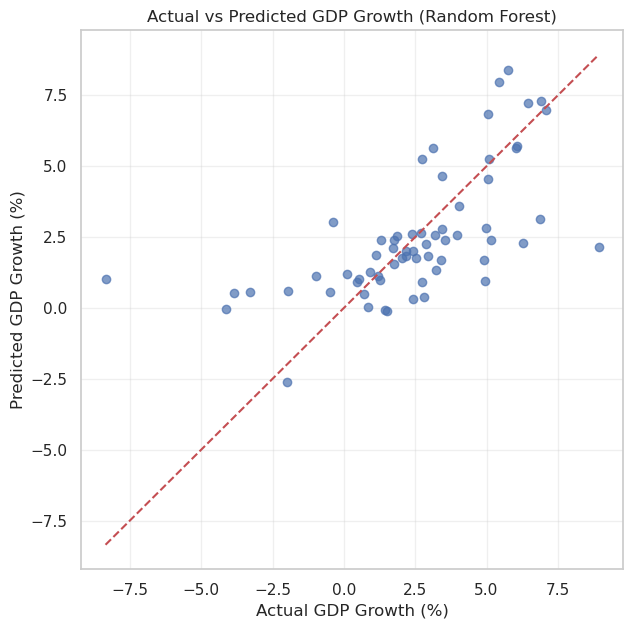

In [59]:
plt.figure(figsize=(7,7))
plt.scatter(y_test, pred_rf, alpha=0.7)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)
plt.xlabel("Actual GDP Growth (%)")
plt.ylabel("Predicted GDP Growth (%)")
plt.title("Actual vs Predicted GDP Growth (Random Forest)")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
#Most of the blue points are close to the red dashed line.

#This indicates that the Random Forest model predicts GDP Growth reasonably well.

#The Actual vs Predicted GDP Growth plot shows that the Random Forest model captures the overall trend of GDP Growth effectively. Most predicted values are close to the actual values, indicating good predictive performance. The few deviations from the ideal line suggest that the model has some prediction error but still generalizes well to unseen data.